# Haptic Guidance Experiment Analysis

Loads experiment records and computed metrics from the SQLite database.
Experiments are ingested from CSV files (one per run) via `web_gui/ingest_csv.py`.
Collision and wasted-click counts are ingested via `web_gui/ingest_metadata.py`.

**Study design** — 3 between-subjects conditions (n≈6 each):
- `ExpertControlled` — haptic guidance from expert teleoperation
- `WaypointGuidance` — waypoint-based haptic guidance
- `Control` — no intervention

**Session structure per participant:**
1. **Calibration** (first 3 Training runs, no intervention) → pre-intervention baseline
2. **Test1** → pre-test performance
3. **Intervention Training** (remaining Training runs, with guidance except Control)
4. **Test2** → post-test performance

**Core research question:** Does the intervention improve Test1 → Test2 performance,
and does the improvement differ by condition?

In [1]:
import re
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from itertools import combinations
from pathlib import Path
from scipy.stats import kruskal, mannwhitneyu

DB_PATH       = Path("web_gui/experiments.db")
DATA_ROOT     = Path("../data_analysis")
WAYPOINTS_DIR = Path("waypoints")

# Core metrics tracked in the analysis
BASE_METRICS = [
    "total_duration",
    "jitter_rms",
    "lateral_error_rms",
    "path_efficiency",
]

# Derived metrics computed after loading
DERIVED_METRICS = [
    "collision_rate",
    "wasted_click_ratio",
    "norm_excess_path",
]

ALL_METRICS = BASE_METRICS + DERIVED_METRICS

METRIC_LABELS = {
    "total_duration":     "Duration (s)",
    "jitter_rms":         "RMS Jitter (m)",
    "lateral_error_rms":  "RMS Lateral Error (m)",
    "path_efficiency":    "Path Efficiency (%)",
    "collision_rate":     "Collision Rate (per s)",
    "wasted_click_ratio": "Wasted Click Rate (per s)",
    "norm_excess_path":   "Normalised Excess Path",
}

CONDITION_COLOURS = {
    "ExpertControlled": "#e06c75",
    "WaypointGuidance":  "#61afef",
    "Control":           "#98c379",
}

## Discover data files

Dynamically scans `DATA_ROOT` for all participant CSVs.
Filename format: `{PID}_{Condition}_{Scenario}_{DDMmmYYYY}_{HH-MM-SS}.csv`

Run `web_gui/ingest_csv.py <participant_dir>` on any folder shown here to add it to the database.

In [2]:
FILENAME_RE = re.compile(
    r'^(?P<pid>[^_]+)_(?P<condition>[^_]+)_(?P<scenario>[^_]+)_'
    r'(?P<date>\d{2}[A-Za-z]{3}\d{4})_(?P<time>\d{2}-\d{2}-\d{2})\.csv$'
)

discovered = []
for csv_path in sorted(DATA_ROOT.rglob("*.csv")):
    m = FILENAME_RE.match(csv_path.name)
    if not m:
        continue
    scenario = m.group('scenario')
    waypoint_scenario = 'Training' if scenario == 'Calibration' else scenario
    ref = WAYPOINTS_DIR / f"{waypoint_scenario}.csv"
    discovered.append({
        "participant":      m.group('pid'),
        "condition":        m.group('condition'),
        "scenario":         scenario,
        "date":             m.group('date'),
        "time":             m.group('time'),
        "reference_exists": ref.exists(),
        "path":             str(csv_path),
    })

disc_df = pd.DataFrame(discovered)
print(f"Discovered {len(disc_df)} CSV file(s) across "
      f"{disc_df['participant'].nunique()} participant(s)")
print(f"Conditions : {sorted(disc_df['condition'].unique())}")
print(f"Scenarios  : {sorted(disc_df['scenario'].unique())}")
disc_df.groupby(["participant", "condition", "scenario"]).size().rename("files").reset_index()

Discovered 181 CSV file(s) across 18 participant(s)
Conditions : ['Control', 'ExpertControlled', 'WaypointGuidance']
Scenarios  : ['Calibration', 'Test1', 'Test2', 'Training']


,participant,condition,scenario,files
0,P001,ExpertControlled,Calibration,3
1,P001,ExpertControlled,Test1,1
2,P001,ExpertControlled,Test2,1
3,P001,ExpertControlled,Training,5
4,P002,WaypointGuidance,Calibration,3
...,...,...,...,...
67,P017,Control,Training,5
68,P018,Control,Calibration,3
69,P018,Control,Test1,1
70,P018,Control,Test2,1


## Load from database

In [3]:
with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql("""
        SELECT
            e.id,
            e.run_id,
            e.participant_id,
            e.condition,
            e.scenario,
            e.timestamp,
            e.duration,
            m.total_duration,
            m.jitter_rms,
            m.jitter_mean,
            m.jitter_std,
            m.jitter_p2p,
            m.lateral_error_rms,
            m.lateral_error_mean,
            m.lateral_error_std,
            m.path_efficiency,
            m.ideal_path_length,
            m.actual_path_length,
            m.excess_path_length,
            m.collisions,
            m.wasted_clicks
        FROM experiments e
        JOIN metrics m ON e.id = m.experiment_id
        WHERE e.status = 'completed'
        ORDER BY e.participant_id, e.scenario, e.timestamp
    """, conn)

df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])

print(f"{len(df_raw)} completed experiment(s) loaded")
print(f"Participants : {sorted(df_raw['participant_id'].unique())}")
print(f"Conditions   : {sorted(df_raw['condition'].unique())}")
print(f"Scenarios    : {sorted(df_raw['scenario'].unique())}")
df_raw.head()

181 completed experiment(s) loaded
Participants : ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008', 'P009', 'P010', 'P011', 'P012', 'P013', 'P014', 'P015', 'P016', 'P017', 'P018']
Conditions   : ['Control', 'ExpertControlled', 'WaypointGuidance']
Scenarios    : ['Calibration', 'Test1', 'Test2', 'Training']


,id,run_id,participant_id,condition,scenario,timestamp,duration,total_duration,jitter_rms,jitter_mean,...,jitter_p2p,lateral_error_rms,lateral_error_mean,lateral_error_std,path_efficiency,ideal_path_length,actual_path_length,excess_path_length,collisions,wasted_clicks
0,1,P001_ExpertControlled_Calibration_2026-03-30T2...,P001,ExpertControlled,Calibration,2026-03-30 23:21:05,8.9530,8.9530,0.001424,0.001123,...,0.004009,0.081682,0.061565,0.053681,66.236845,1.164916,1.758713,0.593797,2.0,0.0
1,2,P001_ExpertControlled_Calibration_2026-03-30T2...,P001,ExpertControlled,Calibration,2026-03-30 23:21:20,5.6566,5.6566,0.001789,0.001360,...,0.005128,0.061855,0.048020,0.038988,78.816730,1.164916,1.478006,0.313090,0.0,0.0
2,3,P001_ExpertControlled_Calibration_2026-03-30T2...,P001,ExpertControlled,Calibration,2026-03-30 23:21:34,3.7981,3.7981,0.003562,0.002091,...,0.013265,0.076217,0.053476,0.054308,71.168202,1.164916,1.636849,0.471933,0.0,1.0
3,4,P001_ExpertControlled_Test1_2026-03-30T23-22-16,P001,ExpertControlled,Test1,2026-03-30 23:22:16,6.7157,6.7157,0.001170,0.000904,...,0.003282,0.051237,0.043318,0.027365,90.758007,1.040654,1.146625,0.105971,0.0,0.0
4,5,P001_ExpertControlled_Test2_2026-03-30T23-24-00,P001,ExpertControlled,Test2,2026-03-30 23:24:00,6.9766,6.9766,0.001127,0.000926,...,0.003039,0.060975,0.053498,0.029256,94.080709,1.145856,1.217950,0.072094,1.0,1.0


## Derived metrics

| Metric | Formula | Interpretation |
|---|---|---|
| `collision_rate` | collisions / total_duration | Collisions per second — lower is better |
| `wasted_click_ratio` | wasted_clicks / total_duration | Wasted actuations per second — lower is better |
| `norm_excess_path` | excess_path_length / ideal_path_length | Fractional detour from ideal path — lower is better |

In [4]:
df = df_raw.copy()

# Derived metrics
df["collision_rate"]     = df["collisions"]    / df["total_duration"].replace(0, np.nan)
df["wasted_click_ratio"] = df["wasted_clicks"] / df["total_duration"].replace(0, np.nan)
df["norm_excess_path"]   = df["excess_path_length"] / df["ideal_path_length"].replace(0, np.nan)

# Classify phase
df["phase"] = df["scenario"].map({
    "Calibration": "Calibration",
    "Training":    "InterventionTraining",
    "Test1":       "Test1",
    "Test2":       "Test2",
})

# Classify attempt type
df["attempt_type"] = df["scenario"].apply(
    lambda s: "test" if s.lower().startswith("test") else "training"
)

# Attempt number within each participant + scenario group
df["attempt_no"] = (
    df.groupby(["participant_id", "scenario"]).cumcount() + 1
)

print("Derived metrics computed: collision_rate, wasted_click_ratio, norm_excess_path")
df[["participant_id", "condition", "scenario", "phase", "attempt_no",
    "collision_rate", "wasted_click_ratio", "norm_excess_path"]].head(10)

Derived metrics computed: collision_rate, wasted_click_ratio, norm_excess_path


,participant_id,condition,scenario,phase,attempt_no,collision_rate,wasted_click_ratio,norm_excess_path
0,P001,ExpertControlled,Calibration,Calibration,1,0.223389,0.000000,0.509734
1,P001,ExpertControlled,Calibration,Calibration,2,0.000000,0.000000,0.268766
2,P001,ExpertControlled,Calibration,Calibration,3,0.000000,0.263290,0.405122
3,P001,ExpertControlled,Test1,Test1,1,0.000000,0.000000,0.101831
4,P001,ExpertControlled,Test2,Test2,1,0.143336,0.143336,0.062917
5,P001,ExpertControlled,Training,InterventionTraining,1,0.247091,0.000000,0.376474
6,P001,ExpertControlled,Training,InterventionTraining,2,0.140174,0.000000,0.522868
7,P001,ExpertControlled,Training,InterventionTraining,3,0.183419,0.000000,0.746045
8,P001,ExpertControlled,Training,InterventionTraining,4,0.000000,0.000000,0.104961
9,P001,ExpertControlled,Training,InterventionTraining,5,0.161907,0.161907,0.362497


## Overview

In [5]:
print("Participants:", sorted(df["participant_id"].unique()))
print("Conditions:  ", sorted(df["condition"].unique()))
print("Scenarios:   ", sorted(df["scenario"].unique()))
print()
df.groupby(["participant_id", "condition", "scenario"]).size().rename("attempts").reset_index()

Participants: ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008', 'P009', 'P010', 'P011', 'P012', 'P013', 'P014', 'P015', 'P016', 'P017', 'P018']
Conditions:   ['Control', 'ExpertControlled', 'WaypointGuidance']
Scenarios:    ['Calibration', 'Test1', 'Test2', 'Training']



,participant_id,condition,scenario,attempts
0,P001,ExpertControlled,Calibration,3
1,P001,ExpertControlled,Test1,1
2,P001,ExpertControlled,Test2,1
3,P001,ExpertControlled,Training,5
4,P002,WaypointGuidance,Calibration,3
...,...,...,...,...
67,P017,Control,Training,5
68,P018,Control,Calibration,3
69,P018,Control,Test1,1
70,P018,Control,Test2,1


## Calibration baseline

The first 3 Training runs per participant (`Calibration` scenario) were recorded
**without any intervention** regardless of condition assignment.
Their mean forms a condition-independent baseline for each participant.

In [6]:
calib_df = df[df["scenario"] == "Calibration"].copy()

calib_baseline = (
    calib_df.groupby(["participant_id", "condition"])[ALL_METRICS]
    .mean()
    .rename(columns={m: f"calib_{m}" for m in ALL_METRICS})
    .reset_index()
)

print(f"Calibration runs: {len(calib_df)} total across {calib_df['participant_id'].nunique()} participants")
print()
calib_baseline.round(4)

Calibration runs: 54 total across 18 participants



,participant_id,condition,calib_total_duration,calib_jitter_rms,calib_lateral_error_rms,calib_path_efficiency,calib_collision_rate,calib_wasted_click_ratio,calib_norm_excess_path
0,P001,ExpertControlled,6.1359,0.0023,0.0733,72.0739,0.0745,0.0878,0.3945
1,P002,WaypointGuidance,3.8493,0.0031,0.0478,94.4344,0.2356,0.0865,0.0767
2,P003,ExpertControlled,22.1743,0.0009,0.1844,52.4637,0.0253,0.0000,1.1649
3,P004,WaypointGuidance,6.5772,0.0015,0.0416,93.5666,0.0000,0.0422,0.0755
4,P005,Control,3.9003,0.0031,0.0815,73.8716,0.2332,0.0000,0.3631
5,P006,ExpertControlled,12.8029,0.0010,0.0459,80.4835,0.0000,0.0676,0.2497
6,P007,WaypointGuidance,16.7138,0.0008,0.1027,73.7842,0.0300,0.0000,0.3869
7,P008,WaypointGuidance,28.9119,0.0006,0.1380,56.0168,0.0666,0.0207,0.7952
8,P009,ExpertControlled,11.6443,0.0014,0.1025,56.5604,0.2643,0.1143,0.8892
9,P010,Control,12.4843,0.0012,0.0679,67.6346,0.0000,0.1326,0.5896


## Training progression

**Calibration phase** (first 3 runs, no intervention) shown with dashed lines.
**Intervention phase** (remaining Training runs, with guidance for EC and WG) shown with solid lines.
Attempt numbers restart within each phase.
Colours encode condition.

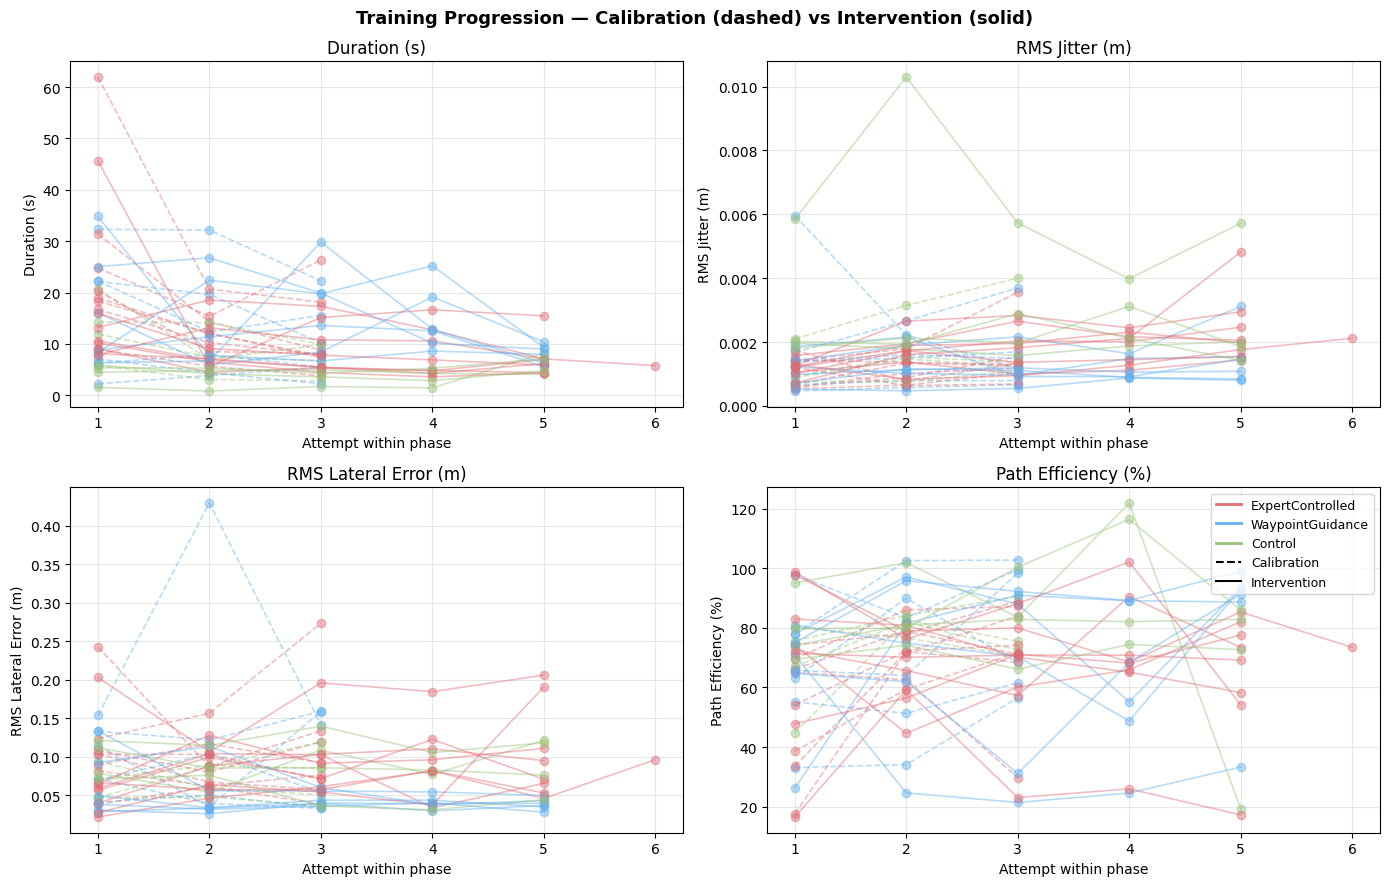

In [7]:
CONDITION_FILTER = None   # e.g. "ExpertControlled", or None for all
PLOT_METRICS = ["total_duration", "jitter_rms", "lateral_error_rms", "path_efficiency"]

calib_part = df[df["scenario"] == "Calibration"].copy()
interv_part = df[df["scenario"] == "Training"].copy()

for part in [calib_part, interv_part]:
    part["attempt_no"] = part.groupby("participant_id").cumcount() + 1

if CONDITION_FILTER:
    calib_part  = calib_part[calib_part["condition"]  == CONDITION_FILTER]
    interv_part = interv_part[interv_part["condition"] == CONDITION_FILTER]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Training Progression — Calibration (dashed) vs Intervention (solid)",
    fontsize=13, fontweight="bold"
)

for ax, metric in zip(axes.flat, PLOT_METRICS):
    for pid, grp in calib_part.groupby("participant_id"):
        colour = CONDITION_COLOURS.get(grp["condition"].iloc[0], "grey")
        ax.plot(grp["attempt_no"], grp[metric],
                linestyle="--", marker="o", color=colour, alpha=0.45, linewidth=1.2)
    for pid, grp in interv_part.groupby("participant_id"):
        colour = CONDITION_COLOURS.get(grp["condition"].iloc[0], "grey")
        ax.plot(grp["attempt_no"], grp[metric],
                linestyle="-", marker="o", color=colour, alpha=0.45, linewidth=1.2)
    ax.set_xlabel("Attempt within phase")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(METRIC_LABELS[metric])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3)

legend_handles = [
    Line2D([0], [0], color=c, label=cond, linewidth=2)
    for cond, c in CONDITION_COLOURS.items()
] + [
    Line2D([0], [0], color="black", linestyle="--", label="Calibration"),
    Line2D([0], [0], color="black", linestyle="-",  label="Intervention"),
]
axes.flat[-1].legend(handles=legend_handles, fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

## Aggregate progression by phase

Thin lines = individual participants (coloured by condition).
Bold black line = group mean; shaded band = ±1 std.

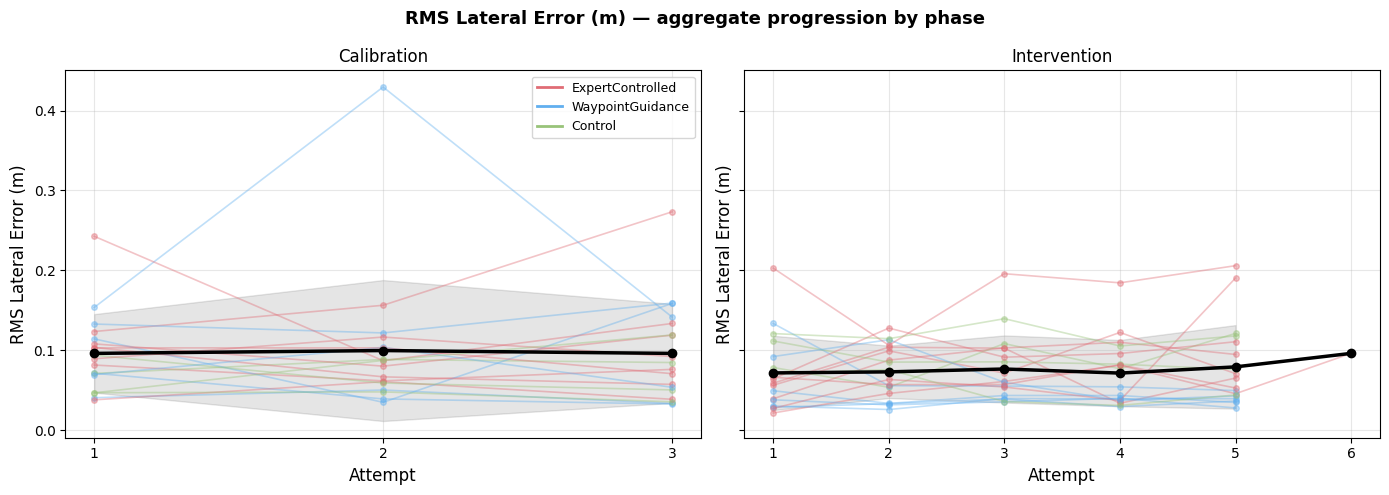

In [8]:
METRIC    = "lateral_error_rms"   # change to any metric in ALL_METRICS
CONDITION = None                  # e.g. "ExpertControlled", or None for all

phases = [
    ("Calibration",   "Calibration"),
    ("Intervention",  "Training"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle(
    f"{METRIC_LABELS[METRIC]} — aggregate progression by phase",
    fontsize=13, fontweight="bold"
)

for ax, (phase_label, scenario) in zip(axes, phases):
    subset = df[df["scenario"] == scenario].copy()
    if CONDITION:
        subset = subset[subset["condition"] == CONDITION]
    subset["attempt_no"] = subset.groupby("participant_id").cumcount() + 1

    pivot = subset.pivot_table(
        index="attempt_no", columns="participant_id",
        values=METRIC, aggfunc="first"
    )
    agg_mean = pivot.mean(axis=1)
    agg_std  = pivot.std(axis=1)

    for pid in pivot.columns:
        cond = df.loc[df["participant_id"] == pid, "condition"].iloc[0]
        colour = CONDITION_COLOURS.get(cond, "grey")
        ax.plot(pivot.index, pivot[pid],
                color=colour, alpha=0.4, linewidth=1.2, marker="o", markersize=4)
    ax.plot(agg_mean.index, agg_mean,
            color="black", linewidth=2.5, marker="o", markersize=6,
            label="Group mean", zorder=5)
    ax.fill_between(agg_mean.index, agg_mean - agg_std, agg_mean + agg_std,
                    color="black", alpha=0.1, label="±1 std")
    ax.set_xlabel("Attempt", fontsize=12)
    ax.set_ylabel(METRIC_LABELS[METRIC], fontsize=12)
    ax.set_title(phase_label, fontsize=12)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3)

legend_handles = [
    Line2D([0], [0], color=c, label=cond, linewidth=2)
    for cond, c in CONDITION_COLOURS.items()
]
axes[0].legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.show()

## Test results — Test1 vs Test2 by participant

Each line connects one participant's Test1 and Test2 scores.
Downward slope = improvement for error/jitter/duration; upward slope = improvement for efficiency.

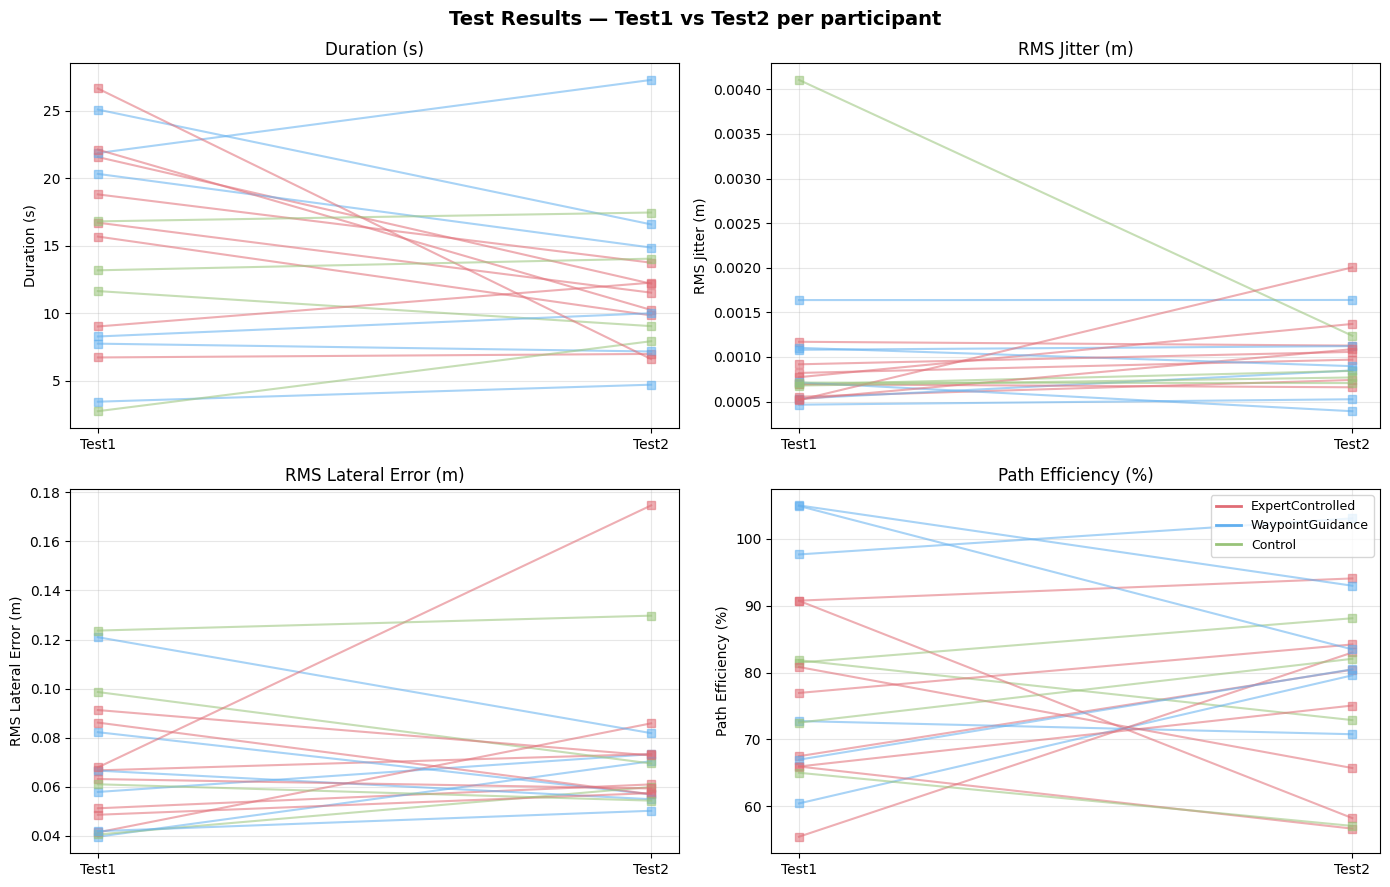

In [9]:
CONDITION_FILTER = None   # e.g. "ExpertControlled"
PLOT_METRICS = ["total_duration", "jitter_rms", "lateral_error_rms", "path_efficiency"]

test = df[df["attempt_type"] == "test"].copy()
if CONDITION_FILTER:
    test = test[test["condition"] == CONDITION_FILTER]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Test Results — Test1 vs Test2 per participant", fontsize=14, fontweight="bold")

for ax, metric in zip(axes.flat, PLOT_METRICS):
    for pid, grp in test.groupby("participant_id"):
        colour = CONDITION_COLOURS.get(grp["condition"].iloc[0], "grey")
        grp_sorted = grp.sort_values("scenario")
        x_vals = [1 if sc == "Test1" else 2 for sc in grp_sorted["scenario"]]
        ax.plot(x_vals, grp_sorted[metric],
                marker="s", color=colour, alpha=0.55, linewidth=1.5)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Test1", "Test2"])
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(METRIC_LABELS[metric])
    ax.grid(True, alpha=0.3)

legend_handles = [
    Line2D([0], [0], color=c, label=cond, linewidth=2)
    for cond, c in CONDITION_COLOURS.items()
]
axes.flat[-1].legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.show()

## Test1 → Test2 delta (Δ)

**Core analysis.** Δ = Test2 − Test1 per participant per metric.

- Negative Δ = improvement for: `total_duration`, `jitter_rms`, `lateral_error_rms`, `collision_rate`, `wasted_click_ratio`, `norm_excess_path`
- Positive Δ = improvement for: `path_efficiency`

In [10]:
# Pivot to get one row per participant with Test1 and Test2 columns side-by-side
test_pivot = (
    df[df["attempt_type"] == "test"]
    .pivot_table(
        index=["participant_id", "condition"],
        columns="scenario",
        values=ALL_METRICS,
        aggfunc="first",
    )
)
test_pivot.columns = [f"{m}_{sc}" for m, sc in test_pivot.columns]
test_pivot = test_pivot.reset_index()

# Compute deltas
delta_df = test_pivot[["participant_id", "condition"]].copy()
for m in ALL_METRICS:
    c1, c2 = f"{m}_Test1", f"{m}_Test2"
    if c1 in test_pivot.columns and c2 in test_pivot.columns:
        delta_df[f"delta_{m}"] = test_pivot[c2] - test_pivot[c1]

DELTA_COLS = [c for c in delta_df.columns if c.startswith("delta_")]

print(f"Delta computed for {len(delta_df)} participants")
delta_df[["participant_id", "condition"] + DELTA_COLS].round(4)

Delta computed for 18 participants


,participant_id,condition,delta_total_duration,delta_jitter_rms,delta_lateral_error_rms,delta_path_efficiency,delta_collision_rate,delta_wasted_click_ratio,delta_norm_excess_path
0,P001,ExpertControlled,0.2609,-0.0000,0.0097,3.3227,0.1433,0.1433,-0.0389
1,P002,WaypointGuidance,1.2608,0.0000,0.0154,-12.0142,0.4256,0.0000,0.1230
2,P003,ExpertControlled,-9.3801,0.0002,0.0067,12.9344,0.0000,-0.0464,-0.2383
3,P004,WaypointGuidance,-0.5795,0.0000,0.0308,5.3887,0.1397,-0.1292,-0.0535
4,P005,Control,5.1837,-0.0029,-0.0291,-8.9504,-0.9709,0.2526,0.1500
5,P006,ExpertControlled,-5.1823,0.0006,0.0444,-32.5061,0.2605,-0.1797,0.6152
6,P007,WaypointGuidance,-8.5046,0.0001,-0.0391,19.1577,0.0000,0.0000,-0.3983
7,P008,WaypointGuidance,-5.4589,0.0003,-0.0253,-1.9732,-0.1607,0.0000,0.0383
8,P009,ExpertControlled,-5.8395,0.0001,-0.0292,27.5507,-0.0638,-0.4467,-0.5986
9,P010,Control,-2.5960,0.0002,0.0194,6.6274,0.0000,-0.0613,-0.0923


## Condition comparison — Δ (Test2 − Test1)

Bars = mean Δ per condition; error bars = ±1 std across participants.
Dashed line at 0 = no change from Test1 to Test2.

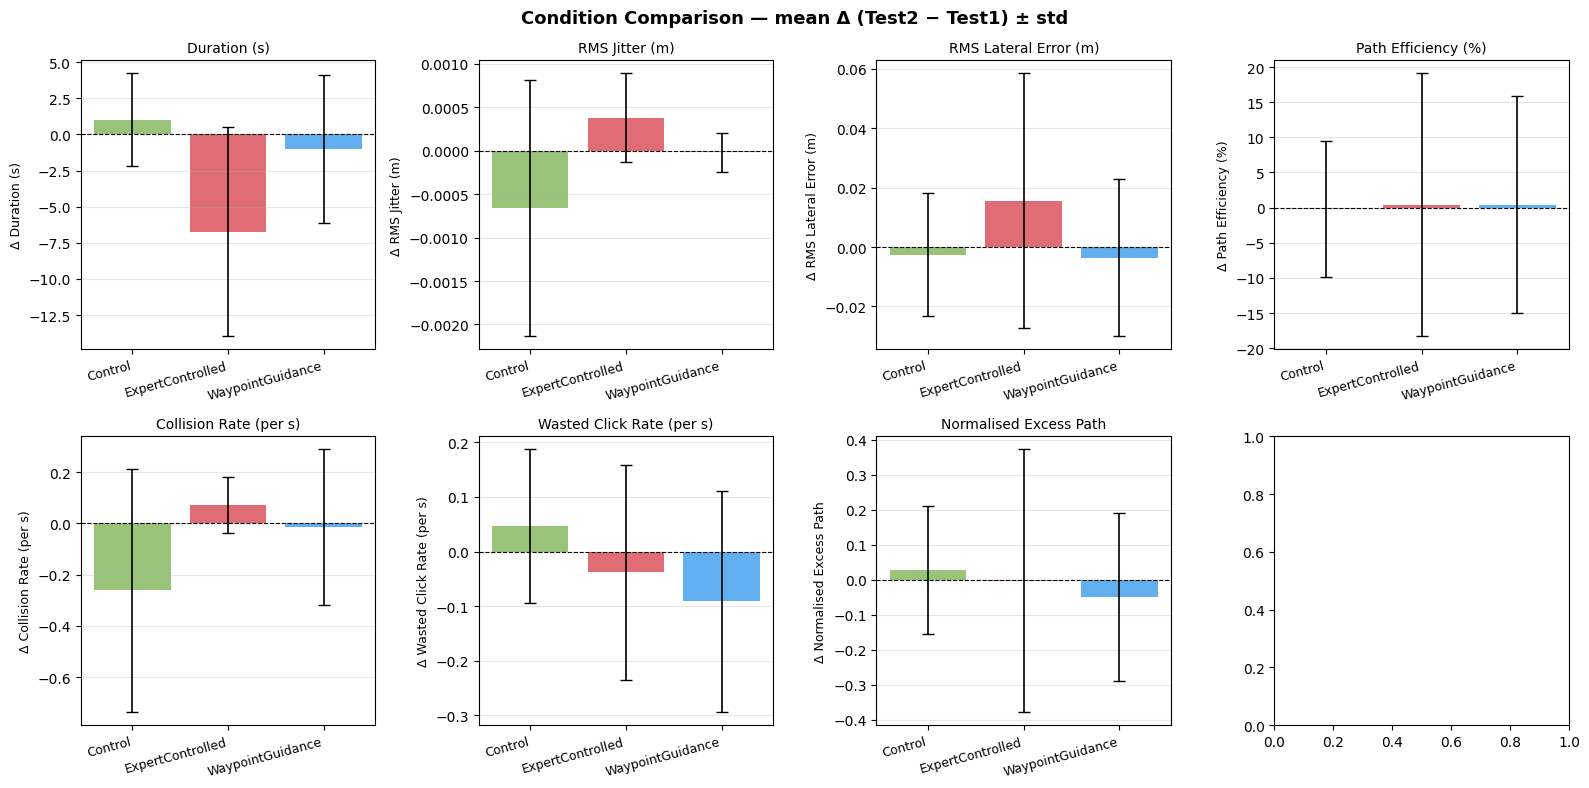

In [11]:
delta_summary = delta_df.groupby("condition")[DELTA_COLS].agg(["mean", "std"]).reset_index()
conditions    = sorted(delta_df["condition"].unique())
x             = list(range(len(conditions)))
colours       = [CONDITION_COLOURS.get(c, "grey") for c in conditions]

ncols = 4
nrows = -(-len(DELTA_COLS) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]
fig.suptitle(
    "Condition Comparison — mean Δ (Test2 − Test1) ± std",
    fontsize=13, fontweight="bold"
)

for ax, col in zip(axes_flat, DELTA_COLS):
    metric_name = col.replace("delta_", "")
    means = [
        delta_summary.loc[delta_summary["condition"] == c, (col, "mean")].values[0]
        if c in delta_summary["condition"].values else float("nan")
        for c in conditions
    ]
    errs = [
        delta_summary.loc[delta_summary["condition"] == c, (col, "std")].values[0]
        if c in delta_summary["condition"].values else float("nan")
        for c in conditions
    ]
    ax.bar(x, means, color=colours, yerr=errs, capsize=4,
           error_kw={"elinewidth": 1.2, "ecolor": "black"})
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel(f"Δ {METRIC_LABELS.get(metric_name, metric_name)}", fontsize=9)
    ax.set_title(METRIC_LABELS.get(metric_name, metric_name), fontsize=10)
    ax.grid(axis="y", alpha=0.3)

for ax in list(axes_flat)[len(DELTA_COLS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Statistical tests — Kruskal-Wallis + pairwise Mann-Whitney U

Non-parametric tests are appropriate given small group sizes (n≈6) and no normality assumption.

- **Kruskal-Wallis H**: omnibus test across all 3 conditions on Δ values.
  `*` = p < 0.05.
- **Pairwise Mann-Whitney U**: post-hoc comparisons. Bonferroni correction applied
  (α/3 per metric, since 3 pairs).

In [12]:
conditions_list = sorted(delta_df["condition"].unique())
pairs           = list(combinations(conditions_list, 2))
alpha           = 0.05
bonf_alpha      = alpha / len(pairs)

results = []
for col in DELTA_COLS:
    groups = {
        c: delta_df.loc[delta_df["condition"] == c, col].dropna().values
        for c in conditions_list
    }
    if any(len(g) < 2 for g in groups.values()):
        continue

    try:
        h_stat, p_kw = kruskal(*groups.values())
    except Exception:
        h_stat, p_kw = float("nan"), float("nan")

    pairwise = {}
    for c1, c2 in pairs:
        try:
            _, p_mw = mannwhitneyu(groups[c1], groups[c2], alternative="two-sided")
            sig = "*" if p_mw < bonf_alpha else ""
            pairwise[f"{c1[:4]} vs {c2[:4]}"] = f"{p_mw:.4f}{sig}"
        except Exception:
            pairwise[f"{c1[:4]} vs {c2[:4]}"] = "—"

    metric_name = col.replace("delta_", "")
    row = {
        "metric":  metric_name,
        "KW_H":    round(h_stat, 3),
        "KW_p":    round(p_kw, 4),
        "KW_sig":  "*" if p_kw < alpha else "",
    }
    row.update(pairwise)
    results.append(row)

stats_df = pd.DataFrame(results)
print(f"Bonferroni-corrected pairwise threshold: α = {bonf_alpha:.4f}")
print(f"  (* in pairwise columns = p < {bonf_alpha:.4f})")
print()
stats_df

Bonferroni-corrected pairwise threshold: α = 0.0167
  (* in pairwise columns = p < 0.0167)



,metric,KW_H,KW_p,KW_sig,Cont vs Expe,Cont vs Wayp,Expe vs Wayp
0,total_duration,4.387,0.1115,,0.0485,0.9143,0.1812
1,jitter_rms,3.484,0.1752,,0.2141,1.0000,0.1079
2,lateral_error_rms,0.642,0.7255,,0.5697,1.0000,0.5728
3,path_efficiency,0.000,1.0000,,1.0000,1.0000,1.0000
4,collision_rate,3.464,0.1769,,0.0644,0.5895,0.3608
5,wasted_click_ratio,0.281,0.8688,,0.9318,0.8259,0.6440
6,norm_excess_path,0.243,0.8857,,0.9333,0.7619,0.7546


## Absolute test performance by condition

Mean metric per condition and test scenario (Test1 / Test2), as context for the delta analysis above.
Note: direct comparison of absolute values conflates baseline differences between conditions.

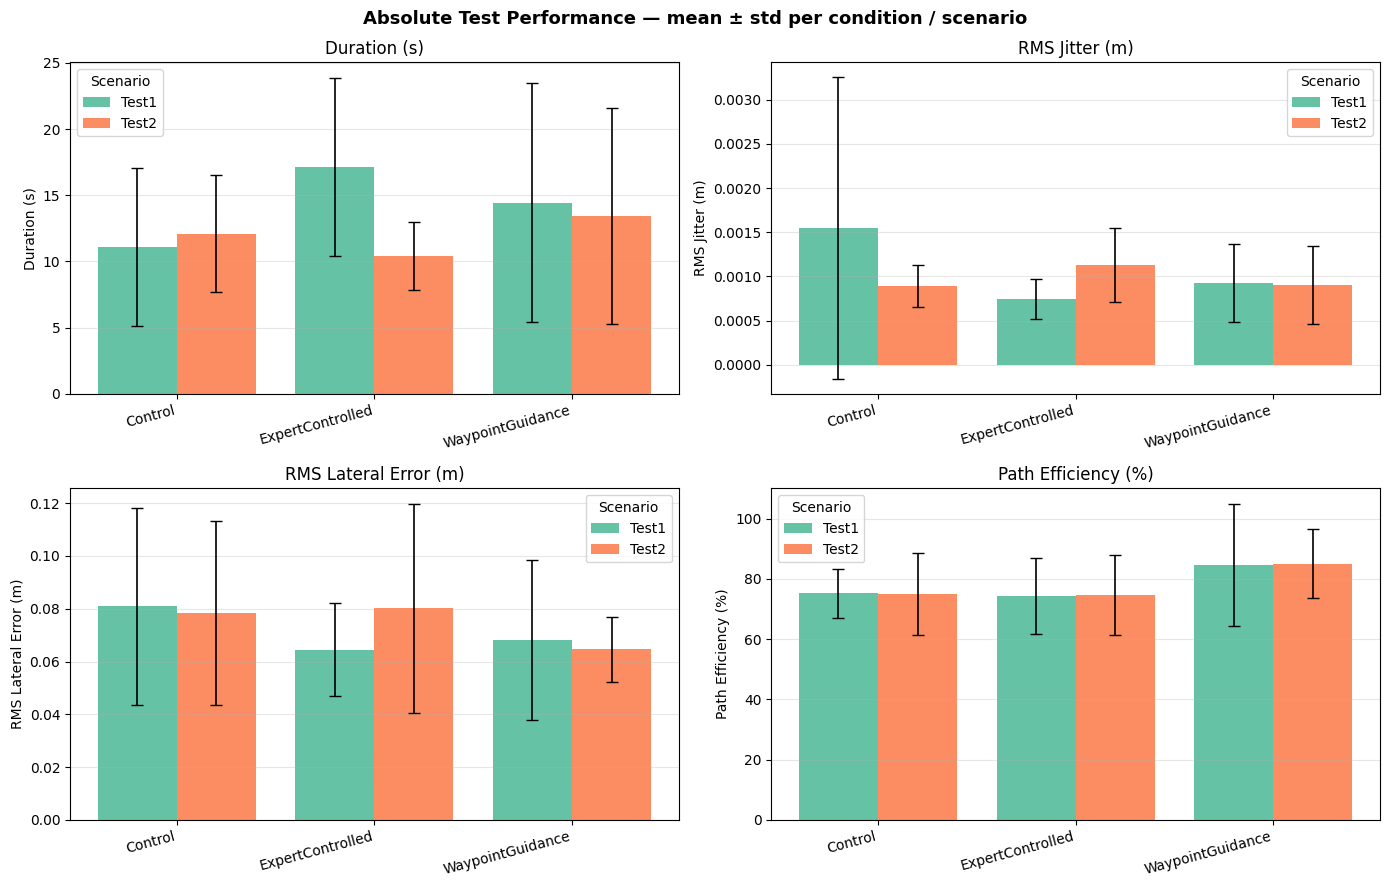

In [13]:
PLOT_METRICS = ["total_duration", "jitter_rms", "lateral_error_rms", "path_efficiency"]

subset = df[df["attempt_type"] == "test"].copy()
conditions_sorted = sorted(subset["condition"].unique())
scenarios_sorted  = sorted(subset["scenario"].unique())

summary = (
    subset.groupby(["condition", "scenario"])[PLOT_METRICS]
    .agg(["mean", "std"])
    .reset_index()
)

x          = list(range(len(conditions_sorted)))
n_sc       = len(scenarios_sorted)
width      = 0.8 / n_sc
colours    = plt.cm.Set2.colors

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Absolute Test Performance — mean ± std per condition / scenario",
    fontsize=13, fontweight="bold"
)

for ax, metric in zip(axes.flat, PLOT_METRICS):
    for i, sc in enumerate(scenarios_sorted):
        means, errs = [], []
        for cond in conditions_sorted:
            row = summary.loc[(summary["condition"] == cond) & (summary["scenario"] == sc)]
            means.append(row[(metric, "mean")].values[0] if not row.empty else float("nan"))
            errs.append(row[(metric, "std")].values[0]  if not row.empty else float("nan"))
        offset = (i - (n_sc - 1) / 2) * width
        ax.bar(
            [xi + offset for xi in x], means, width,
            yerr=errs, capsize=4,
            error_kw={"elinewidth": 1.2, "ecolor": "black"},
            label=sc, color=colours[i % len(colours)]
        )
    ax.set_xticks(x)
    ax.set_xticklabels(conditions_sorted, rotation=15, ha="right")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(METRIC_LABELS[metric])
    ax.legend(title="Scenario")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Per-participant summary table

In [14]:
SUMMARY_METRICS = ["total_duration", "jitter_rms", "lateral_error_rms",
                   "path_efficiency", "collision_rate", "wasted_click_ratio", "norm_excess_path"]
df.groupby(["participant_id", "condition", "scenario"])[SUMMARY_METRICS].agg(["mean", "std"]).round(4)

total_duration         jitter_rms  \
                                                      mean     std       mean   
participant_id condition        scenario                                        
P001           ExpertControlled Calibration         6.1359  2.6107     0.0023   
                                Test1               6.7157     NaN     0.0012   
                                Test2               6.9766     NaN     0.0011   
                                Training            6.2261  1.4771     0.0021   
P002           WaypointGuidance Calibration         3.8493  1.6117     0.0031   
...                                                    ...     ...        ...   
P017           Control          Training            5.4695  1.0000     0.0021   
P018           Control          Calibration         8.6857  2.8031     0.0013   
                                Test1              13.1699     NaN     0.0007   
                                Test2              14.0320     NaN     0.0007   
                                Training            4.2569  1.1511     0.0022   

                                                    lateral_error_rms          \
                                                std              mean     std   
participant_id condition        scenario                                        
P001           ExpertControlled Calibration  0.0011            0.0733  0.0102   
                                Test1           NaN            0.0512     NaN   
                                Test2           NaN            0.0610     NaN   
                                Training     0.0004            0.0730  0.0301   
P002           WaypointGuidance Calibration  0.0025            0.0478  0.0207   
...                                             ...               ...     ...   
P017           Control          Training     0.0005            0.1198  0.0125   
P018           Control          Calibration  0.0003            0.0436  0.0069   
                                Test1           NaN            0.0610     NaN   
                                Test2           NaN            0.0544     NaN   
                                Training     0.0005            0.0516  0.0205   

                                            path_efficiency           \
                                                       mean      std   
participant_id condition        scenario                               
P001           ExpertControlled Calibration         72.0739   6.3387   
                                Test1               90.7580      NaN   
                                Test2               94.0807      NaN   
                                Training            71.8966  12.2640   
P002           WaypointGuidance Calibration         94.4344  14.2029   
...                                                     ...      ...   
P017           Control          Training            71.3842   3.5385   
P018           Control          Calibration         83.4611   7.4916   
                                Test1               72.5191      NaN   
                                Test2               82.0572      NaN   
                                Training            92.4628  15.7723   

                                            collision_rate          \
                                                      mean     std   
participant_id condition        scenario                             
P001           ExpertControlled Calibration         0.0745  0.1290   
                                Test1               0.0000     NaN   
                                Test2               0.1433     NaN   
                                Training            0.1465  0.0911   
P002           WaypointGuidance Calibration         0.2356  0.2247   
...                                                    ...     ...   
P017           Control          Training            0.0000  0.0000   
P018           Control          Calibration         0.0000  0.000

## Raw data export

In [15]:
# Uncomment to export
# df.to_csv("experiment_results.csv", index=False)
# delta_df.to_csv("experiment_deltas.csv", index=False)
# print("Exported experiment_results.csv and experiment_deltas.csv")